# Step 1: Setting up the Environment

## Install Required Libraries:

In [3]:
!pip install numpy pandas matplotlib seaborn scikit-learn tensorflow keras

## Import the Libraries

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, Flatten, LSTM, SimpleRNN, Dropout
from tensorflow.keras.utils import to_categorical

# Step 2: Loading and Exploring the Dataset

## Code for Loading the Dataset

In [5]:
pip install pyarrow

In [6]:
pip install fastparquet

In [7]:
import pandas as pd

# Load the dataset
# dataset_path = "Dataset/UNSW_NB15_training-set.parquet"
dataset_path = '/content/UNSW_N~2.PAR'
data = pd.read_parquet(dataset_path)

# Display the first few rows
print("Dataset Shape:", data.shape)
print(data.head())

Dataset Shape: (175341, 36)
        dur proto service state  spkts  dpkts  sbytes  dbytes       rate  \
0  0.121478   tcp       -   FIN      6      4     258     172  74.087486   
1  0.649902   tcp       -   FIN     14     38     734   42014  78.473373   
2  1.623129   tcp       -   FIN      8     16     364   13186  14.170161   
3  1.681642   tcp     ftp   FIN     12     12     628     770  13.677108   
4  0.449454   tcp       -   FIN     10      6     534     268  33.373825   

          sload  ...  trans_depth  response_body_len  ct_src_dport_ltm  \
0  14158.942383  ...            0                  0                 1   
1   8395.112305  ...            0                  0                 1   
2   1572.271851  ...            0                  0                 1   
3   2740.178955  ...            0                  0                 1   
4   8561.499023  ...            0                  0                 2   

   ct_dst_sport_ltm  is_ftp_login  ct_ftp_cmd  ct_flw_http_mthd  \
0  

## Exploring the Dataset

### Check for missing values and basic statistics

In [8]:
# Check for missing values
print("Missing Values in Dataset:")
print(data.isnull().sum())

# Display basic statistics
print("\nDataset Statistics:")
print(data.describe())

Missing Values in Dataset:
dur                  0
proto                0
service              0
state                0
spkts                0
dpkts                0
sbytes               0
dbytes               0
rate                 0
sload                0
dload                0
sloss                0
dloss                0
sinpkt               0
dinpkt               0
sjit                 0
djit                 0
swin                 0
stcpb                0
dtcpb                0
dwin                 0
tcprtt               0
synack               0
ackdat               0
smean                0
dmean                0
trans_depth          0
response_body_len    0
ct_src_dport_ltm     0
ct_dst_sport_ltm     0
is_ftp_login         0
ct_ftp_cmd           0
ct_flw_http_mthd     0
is_sm_ips_ports      0
attack_cat           0
label                0
dtype: int64

Dataset Statistics:
                 dur          spkts          dpkts        sbytes  \
count  175341.000000  175341.000000  175341

### View column names to understand the available features

In [9]:
# View column names
print("Column Names:")
print(data.columns)

Column Names:
Index(['dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes',
       'dbytes', 'rate', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt',
       'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt',
       'synack', 'ackdat', 'smean', 'dmean', 'trans_depth',
       'response_body_len', 'ct_src_dport_ltm', 'ct_dst_sport_ltm',
       'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'is_sm_ips_ports',
       'attack_cat', 'label'],
      dtype='object')


## Understand the Target Variable


Target Column Value Counts:
attack_cat
Normal            56000
Generic           40000
Exploits          33393
Fuzzers           18184
DoS               12264
Reconnaissance    10491
Analysis           2000
Backdoor           1746
Shellcode          1133
Worms               130
Name: count, dtype: int64


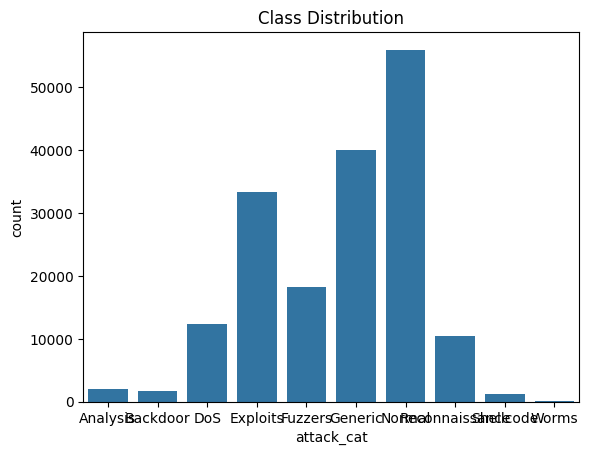

In [10]:
# Count of each target class
print("\nTarget Column Value Counts:")
print(data['attack_cat'].value_counts())

# Visualize class distribution
sns.countplot(x='attack_cat', data=data)
plt.title("Class Distribution")
plt.show()

# Step 3: Data Preprocessing

## Code for Data Preprocessing

### Handle Missing Values

In [11]:
# Drop rows with missing values (if applicable)
data.dropna(inplace=True)
print("Dataset Shape After Dropping Missing Values:", data.shape)

Dataset Shape After Dropping Missing Values: (175341, 36)


### Encode Categorical Variables

In [12]:
# Identify categorical columns
categorical_columns = data.select_dtypes(include=['object']).columns
print("Categorical Columns:", categorical_columns)

# One-hot encode categorical columns
data = pd.get_dummies(data, columns=categorical_columns, drop_first=True)
print("Dataset Shape After Encoding:", data.shape)

Categorical Columns: Index([], dtype='object')
Dataset Shape After Encoding: (175341, 36)


### Normalize Numerical Features

In [13]:
print(data.dtypes)

dur                   float32
proto                category
service              category
state                category
spkts                   int16
dpkts                   int16
sbytes                  int32
dbytes                  int32
rate                  float32
sload                 float32
dload                 float32
sloss                   int16
dloss                   int16
sinpkt                float32
dinpkt                float32
sjit                  float32
djit                  float32
swin                    int16
stcpb                   int64
dtcpb                   int64
dwin                    int16
tcprtt                float32
synack                float32
ackdat                float32
smean                   int16
dmean                   int16
trans_depth             int16
response_body_len       int32
ct_src_dport_ltm         int8
ct_dst_sport_ltm         int8
is_ftp_login             int8
ct_ftp_cmd               int8
ct_flw_http_mthd         int8
is_sm_ips_

In [14]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Separate features and target
X = data.drop(['label', 'attack_cat'], axis=1)  # 'attack_cat' is often excluded if it's not part of the model
y = data['attack_cat']

# Handle categorical columns
categorical_cols = ['proto', 'service', 'state']  # Excluding 'attack_cat' as it's a secondary target or description
X_encoded = pd.get_dummies(X, columns=categorical_cols)

# Normalize numeric features
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_encoded)

# Check the resulting shape
print("Scaled Feature Shape:", X_scaled.shape)

Scaled Feature Shape: (175341, 186)


In [15]:
# prompt: save scaler

import joblib

# Assuming 'scaler' is the MinMaxScaler object you've already created
joblib.dump(scaler, 'scaler.pkl')


['scaler.pkl']

### Split Data into Training and Testing Sets

In [16]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

# Print shapes of training and testing sets
print("Training Set Shape:", X_train.shape)
print("Testing Set Shape:", X_test.shape)

Training Set Shape: (140272, 186)
Testing Set Shape: (35069, 186)


### Convert Target to Categorical

In [17]:
from tensorflow.keras.utils import to_categorical


# Import LabelEncoder
from sklearn.preprocessing import LabelEncoder

# Create a LabelEncoder object
label_encoder = LabelEncoder()

# Fit the encoder to your target variable and transform
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# Now use the encoded target variables with to_categorical
y_train_cat = to_categorical(y_train_encoded)
y_test_cat = to_categorical(y_test_encoded)
print("One-Hot Encoded Target Shape:", y_train_cat.shape)


# # Convert target labels to categorical format
# y_train_cat = to_categorical(y_train)
# y_test_cat = to_categorical(y_test)
print("One-Hot Encoded Target Shape:", y_train_cat.shape)

One-Hot Encoded Target Shape: (140272, 10)
One-Hot Encoded Target Shape: (140272, 10)


In [18]:
# prompt: use label_encoder for displaying the attack labels

# ... (Your existing code)

# Display attack labels using LabelEncoder
attack_labels = label_encoder.classes_
print("Attack labels:", attack_labels)

# Example: To map an encoded label back to original attack label
encoded_label = 0  # Example encoded label
original_label = label_encoder.inverse_transform([encoded_label]) # Use inverse_transform with a list
print(f"Encoded label {encoded_label} corresponds to attack: {original_label[0]}")


Attack labels: ['Analysis' 'Backdoor' 'DoS' 'Exploits' 'Fuzzers' 'Generic' 'Normal'
 'Reconnaissance' 'Shellcode' 'Worms']
Encoded label 0 corresponds to attack: Analysis


# Step 4: Building the Hybrid Machine Learning Model

## Code for Building and Training Individual Models

### Artificial Neural Network (ANN)

In [ ]:
# ANN Model
def build_ann(input_shape):
    model = Sequential([
        Dense(128, activation='relu', input_shape=(input_shape,)),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(y_train_cat.shape[1], activation='softmax')  # Output layer with softmax for classification
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Build and train ANN
ann_model = build_ann(X_train.shape[1])
history_ann = ann_model.fit(X_train, y_train_cat, epochs=10, batch_size=32, validation_split=0.2, verbose=1)

Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3507/3507 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step - accuracy: 0.6641 - loss: 0.9386 - val_accuracy: 0.7449 - val_loss: 0.6664
Epoch 2/10
3507/3507 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - accuracy: 0.7426 - loss: 0.6851 - val_accuracy: 0.7595 - val_loss: 0.6265
Epoch 3/10
3507/3507 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.7512 - loss: 0.6513 - val_accuracy: 0.7655 - val_loss: 0.6072
Epoch 4/10
3507/3507 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.7573 - loss: 0.6353 - val_accuracy: 0.7713 - val_loss: 0.6030
Epoch 5/10
3507/3507 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.7635 - loss: 0.6175 - val_accuracy: 0.7724 - val_loss: 0.5756
Epoch 6/10
3507/3507 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - accuracy: 0.7664 - loss: 0.6045 - val_accuracy: 0.7788 - val_loss: 0.5681
Epoch 7/10
3507/3507 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.7693 - loss: 0.5926 - val_accuracy: 0.7746 - val_loss: 0.5754
Epoch 8/10
3507/3507 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - accuracy: 0.7715 - loss: 0.5844 - val_

In [ ]:
# ann_model.save("ann_model.h5")

### Convolutional Neural Network (CNN)

In [ ]:
# Reshape for CNN input
X_train_cnn = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_cnn = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

# CNN Model
def build_cnn(input_shape):
    model = Sequential([
        Conv1D(32, kernel_size=3, activation='relu', input_shape=input_shape),
        Conv1D(64, kernel_size=3, activation='relu'),
        Flatten(),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dense(y_train_cat.shape[1], activation='softmax')  # Output layer
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Build and train CNN
cnn_model = build_cnn((X_train.shape[1], 1))
history_cnn = cnn_model.fit(X_train_cnn, y_train_cat, epochs=10, batch_size=32, validation_split=0.2, verbose=1)

Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3507/3507 ━━━━━━━━━━━━━━━━━━━━ 58s 16ms/step - accuracy: 0.6877 - loss: 0.8207 - val_accuracy: 0.7575 - val_loss: 0.6124
Epoch 2/10
3507/3507 ━━━━━━━━━━━━━━━━━━━━ 58s 17ms/step - accuracy: 0.7640 - loss: 0.6059 - val_accuracy: 0.7754 - val_loss: 0.5634
Epoch 3/10
3507/3507 ━━━━━━━━━━━━━━━━━━━━ 80s 16ms/step - accuracy: 0.7761 - loss: 0.5658 - val_accuracy: 0.7833 - val_loss: 0.5472
Epoch 4/10
3507/3507 ━━━━━━━━━━━━━━━━━━━━ 54s 16ms/step - accuracy: 0.7817 - loss: 0.5513 - val_accuracy: 0.7874 - val_loss: 0.5393
Epoch 5/10
3507/3507 ━━━━━━━━━━━━━━━━━━━━ 82s 15ms/step - accuracy: 0.7855 - loss: 0.5425 - val_accuracy: 0.7874 - val_loss: 0.5279
Epoch 6/10
3507/3507 ━━━━━━━━━━━━━━━━━━━━ 82s 15ms/step - accuracy: 0.7866 - loss: 0.5326 - val_accuracy: 0.7892 - val_loss: 0.5284
Epoch 7/10
3507/3507 ━━━━━━━━━━━━━━━━━━━━ 55s 16ms/step - accuracy: 0.7878 - loss: 0.5307 - val_accuracy: 0.7938 - val_loss: 0.5193
Epoch 8/10
3507/3507 ━━━━━━━━━━━━━━━━━━━━ 54s 15ms/step - accuracy: 0.7883 - loss: 0.52

In [ ]:
# cnn_model.save("cnn_model.h5")

###  Long Short-Term Memory (LSTM)

In [ ]:
# Reshape for LSTM input
X_train_lstm = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_lstm = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

# LSTM Model
def build_lstm(input_shape):
    model = Sequential([
        LSTM(128, return_sequences=True, input_shape=input_shape),
        LSTM(64),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dense(y_train_cat.shape[1], activation='softmax')  # Output layer
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Build and train LSTM
lstm_model = build_lstm((X_train.shape[1], 1))
history_lstm = lstm_model.fit(X_train_lstm, y_train_cat, epochs=10, batch_size=32, validation_split=0.2, verbose=1)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
3507/3507 ━━━━━━━━━━━━━━━━━━━━ 1205s 342ms/step - accuracy: 0.3103 - loss: 1.7637 - val_accuracy: 0.3213 - val_loss: 1.7397
Epoch 2/10
3507/3507 ━━━━━━━━━━━━━━━━━━━━ 1213s 340ms/step - accuracy: 0.5131 - loss: 1.4010 - val_accuracy: 0.6154 - val_loss: 1.1397
Epoch 3/10
3507/3507 ━━━━━━━━━━━━━━━━━━━━ 1155s 321ms/step - accuracy: 0.5916 - loss: 1.1976 - val_accuracy: 0.6164 - val_loss: 1.0669
Epoch 4/10
3507/3507 ━━━━━━━━━━━━━━━━━━━━ 1239s 343ms/step - accuracy: 0.5894 - loss: 1.1640 - val_accuracy: 0.6083 - val_loss: 1.1008
Epoch 5/10
3507/3507 ━━━━━━━━━━━━━━━━━━━━ 1213s 340ms/step - accuracy: 0.5880 - loss: 1.2014 - val_accuracy: 0.6116 - val_loss: 1.0967
Epoch 6/10
3507/3507 ━━━━━━━━━━━━━━━━━━━━ 1166s 324ms/step - accuracy: 0.6114 - loss: 1.1008 - val_accuracy: 0.5904 - val_loss: 1.0980
Epoch 7/10
3507/3507 ━━━━━━━━━━━━━━━━━━━━ 1219s 341ms/step - accuracy: 0.5669 - loss: 1.1915 - val_accuracy: 0.6045 - val_loss: 1.0675
Epoch 8/10
3507/3507 ━━━━━━━━━━━━━━━━━━━━ 1222s 341ms/s

In [ ]:
# lstm_model.save("lstm_model.h5")

### Recurrent Neural Network (RNN)

In [ ]:
# RNN Model
def build_rnn(input_shape):
    model = Sequential([
        SimpleRNN(128, return_sequences=True, input_shape=input_shape),
        SimpleRNN(64),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dense(y_train_cat.shape[1], activation='softmax')  # Output layer
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Build and train RNN
rnn_model = build_rnn((X_train.shape[1], 1))
history_rnn = rnn_model.fit(X_train_lstm, y_train_cat, epochs=10, batch_size=32, validation_split=0.2, verbose=1)

Epoch 1/10
3507/3507 ━━━━━━━━━━━━━━━━━━━━ 341s 96ms/step - accuracy: 0.5367 - loss: 1.3141 - val_accuracy: 0.5832 - val_loss: 1.1578
Epoch 2/10
3507/3507 ━━━━━━━━━━━━━━━━━━━━ 380s 95ms/step - accuracy: 0.5675 - loss: 1.1988 - val_accuracy: 0.5874 - val_loss: 1.1452
Epoch 3/10
3507/3507 ━━━━━━━━━━━━━━━━━━━━ 399s 100ms/step - accuracy: 0.4577 - loss: 1.5147 - val_accuracy: 0.3222 - val_loss: 1.7362
Epoch 4/10
3507/3507 ━━━━━━━━━━━━━━━━━━━━ 382s 100ms/step - accuracy: 0.3198 - loss: 1.7441 - val_accuracy: 0.3236 - val_loss: 1.7349
Epoch 5/10
3507/3507 ━━━━━━━━━━━━━━━━━━━━ 355s 101ms/step - accuracy: 0.3210 - loss: 1.7433 - val_accuracy: 0.3236 - val_loss: 1.7347
Epoch 6/10
3507/3507 ━━━━━━━━━━━━━━━━━━━━ 367s 97ms/step - accuracy: 0.3203 - loss: 1.7429 - val_accuracy: 0.3236 - val_loss: 1.7352
Epoch 7/10
3507/3507 ━━━━━━━━━━━━━━━━━━━━ 405s 104ms/step - accuracy: 0.3206 - loss: 1.7444 - val_accuracy: 0.3223 - val_loss: 1.7357
Epoch 8/10
3507/3507 ━━━━━━━━━━━━━━━━━━━━ 377s 102ms/step - accur

In [ ]:
# rnn_model.save("rnn_model.h5")

# Step 5: Building the Hybrid Stacking Model (ACLR)

## Load the Saved Models

In [19]:
from tensorflow.keras.models import load_model

# Load saved models
ann_model = load_model("ann_model.h5")
cnn_model = load_model("cnn_model.h5")
lstm_model = load_model("lstm_model.h5")
rnn_model = load_model("rnn_model.h5")
print("Models Loaded Successfully")

Models Loaded Successfully


## Generate Predictions for Stacking

In [ ]:
# Generate predictions for stacking
ann_train_preds = ann_model.predict(X_train)
cnn_train_preds = cnn_model.predict(X_train_cnn)
lstm_train_preds = lstm_model.predict(X_train_lstm)
rnn_train_preds = rnn_model.predict(X_train_lstm)

ann_test_preds = ann_model.predict(X_test)
cnn_test_preds = cnn_model.predict(X_test_cnn)
lstm_test_preds = lstm_model.predict(X_test_lstm)
rnn_test_preds = rnn_model.predict(X_test_lstm)

# Combine predictions into a single dataset for meta-learner
X_train_stack = np.hstack((ann_train_preds, cnn_train_preds, lstm_train_preds, rnn_train_preds))
X_test_stack = np.hstack((ann_test_preds, cnn_test_preds, lstm_test_preds, rnn_test_preds))

print("Stacking Dataset Shapes:")
print("Training:", X_train_stack.shape)
print("Testing:", X_test_stack.shape)

## Train the Meta-Learner

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Train a Logistic Regression meta-learner
meta_learner = LogisticRegression(max_iter=1000)
meta_learner.fit(X_train_stack, np.argmax(y_train_cat, axis=1))

# Make predictions using the meta-learner
y_pred_stack = meta_learner.predict(X_test_stack)

# Evaluate the performance
accuracy = accuracy_score(np.argmax(y_test_cat, axis=1), y_pred_stack)
print(f"Stacking Model Accuracy: {accuracy * 100:.2f}%")

NameError: name 'X_train_stack' is not defined

##  Save the Meta-Learner

In [22]:
import joblib

# Save the meta-learner
joblib.dump(meta_learner, "stacking_meta_learner.pkl")
print("Meta-learner saved successfully.")

Meta-learner saved successfully.


## Load the meta-learner

In [23]:
# Load the meta-learner
meta_learner = joblib.load("stacking_meta_learner.pkl")
print("Meta-learner loaded successfully.")

Meta-learner loaded successfully.


# Step 6: Final Evaluation and Visualization

## Classification Report

In [24]:
from sklearn.metrics import classification_report

# Generate classification report
print("Classification Report:")
print(classification_report(np.argmax(y_test_cat, axis=1), y_pred_stack))

Classification Report:


NameError: name 'y_pred_stack' is not defined

## Confusion Matrix

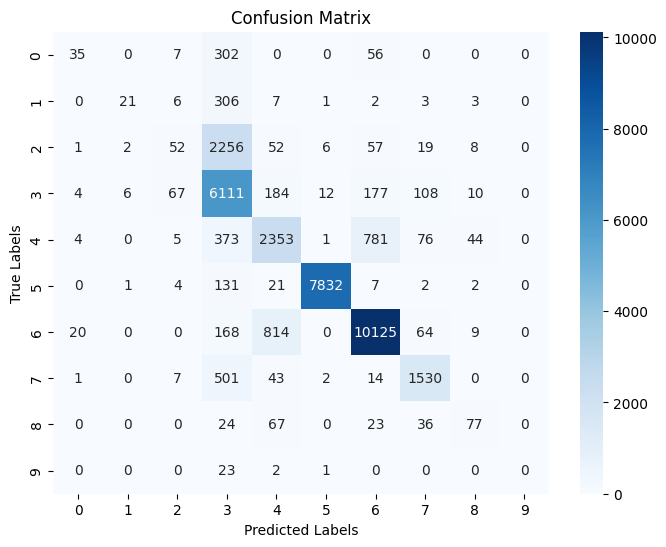

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Confusion Matrix
conf_matrix = confusion_matrix(np.argmax(y_test_cat, axis=1), y_pred_stack)

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=True, yticklabels=True)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()

## ROC-AUC Curve

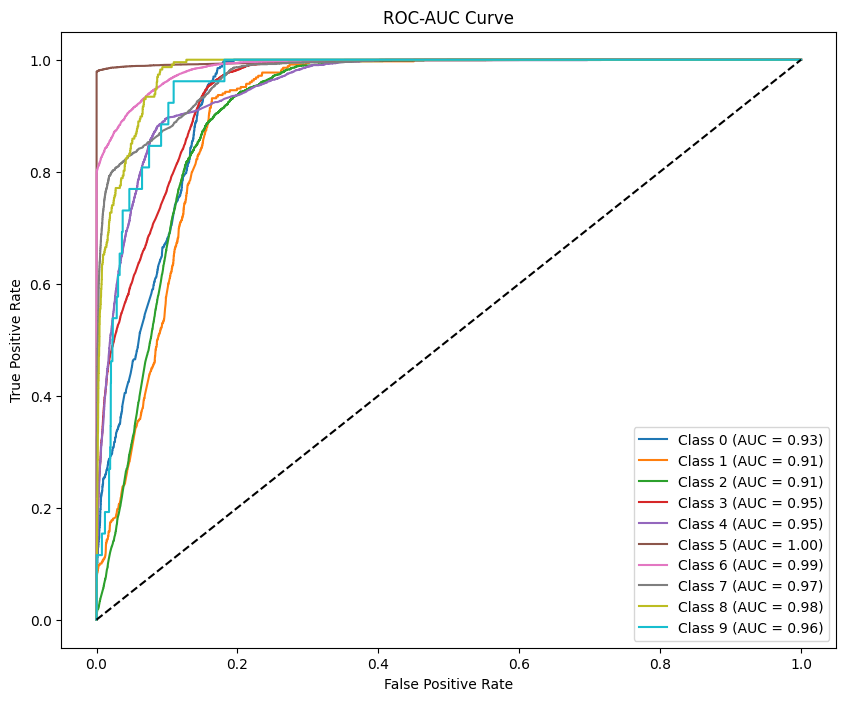

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve, auc

# Calculate ROC-AUC for each class
y_test_labels = np.argmax(y_test_cat, axis=1)
y_pred_prob = meta_learner.predict_proba(X_test_stack)

# One-vs-Rest ROC AUC
fpr = {}
tpr = {}
roc_auc = {}
for i in range(y_test_cat.shape[1]):
    fpr[i], tpr[i], _ = roc_curve(y_test_cat[:, i], y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC Curve for each class
plt.figure(figsize=(10, 8))
for i in range(y_test_cat.shape[1]):
    plt.plot(fpr[i], tpr[i], label=f"Class {i} (AUC = {roc_auc[i]:.2f})")

plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Curve")
plt.legend(loc="lower right")
plt.show()

## Feature Importance

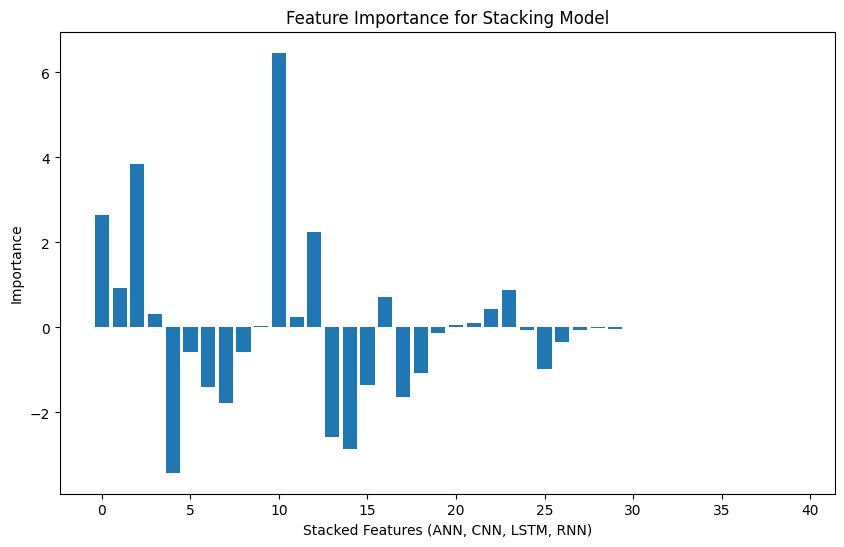

In [ ]:
# Feature importance for Logistic Regression
feature_importance = meta_learner.coef_[0]

# Visualize feature importance
plt.figure(figsize=(10, 6))
plt.bar(range(len(feature_importance)), feature_importance)
plt.xlabel("Stacked Features (ANN, CNN, LSTM, RNN)")
plt.ylabel("Importance")
plt.title("Feature Importance for Stacking Model")
plt.show()

## Performance Comparison

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Function to calculate and return performance metrics
def evaluate_model(model, X_test, y_test_cat, reshape=False):
    # Reshape data if required (for CNN, LSTM, RNN)
    if reshape:
        X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

    # Predict and calculate metrics
    y_pred = model.predict(X_test)
    y_pred_classes = y_pred.argmax(axis=1)
    y_test_classes = y_test_cat.argmax(axis=1)

    accuracy = accuracy_score(y_test_classes, y_pred_classes)
    precision = precision_score(y_test_classes, y_pred_classes, average="weighted")
    recall = recall_score(y_test_classes, y_pred_classes, average="weighted")
    f1 = f1_score(y_test_classes, y_pred_classes, average="weighted")

    return accuracy, precision, recall, f1

# Evaluate individual models
ann_metrics = evaluate_model(ann_model, X_test, y_test_cat)
cnn_metrics = evaluate_model(cnn_model, X_test_cnn, y_test_cat, reshape=True)
lstm_metrics = evaluate_model(lstm_model, X_test_lstm, y_test_cat, reshape=True)
rnn_metrics = evaluate_model(rnn_model, X_test_lstm, y_test_cat, reshape=True)

# Evaluate the stacking model
stacking_predictions = meta_learner.predict(X_test_stack)
stacking_accuracy = accuracy_score(np.argmax(y_test_cat, axis=1), stacking_predictions)
stacking_precision = precision_score(np.argmax(y_test_cat, axis=1), stacking_predictions, average="weighted")
stacking_recall = recall_score(np.argmax(y_test_cat, axis=1), stacking_predictions, average="weighted")
stacking_f1 = f1_score(np.argmax(y_test_cat, axis=1), stacking_predictions, average="weighted")

stacking_metrics = (stacking_accuracy, stacking_precision, stacking_recall, stacking_f1)

# Create a comparison table
comparison_data = {
    "Model": ["ANN", "CNN", "LSTM", "RNN", "Stacking Hybrid Model"],
    "Accuracy": [ann_metrics[0], cnn_metrics[0], lstm_metrics[0], rnn_metrics[0], stacking_metrics[0]],
    "Precision": [ann_metrics[1], cnn_metrics[1], lstm_metrics[1], rnn_metrics[1], stacking_metrics[1]],
    "Recall": [ann_metrics[2], cnn_metrics[2], lstm_metrics[2], rnn_metrics[2], stacking_metrics[2]],
    "F1-Score": [ann_metrics[3], cnn_metrics[3], lstm_metrics[3], rnn_metrics[3], stacking_metrics[3]],
}

# Convert to DataFrame for display
comparison_df = pd.DataFrame(comparison_data)

# Display the comparison table
print("Model Performance Comparison:")
print(comparison_df)

1096/1096 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
  12/1096 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step  

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


1096/1096 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


1096/1096 ━━━━━━━━━━━━━━━━━━━━ 107s 97ms/step
   4/1096 ━━━━━━━━━━━━━━━━━━━━ 26s 24ms/step

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


1096/1096 ━━━━━━━━━━━━━━━━━━━━ 31s 28ms/step
Model Performance Comparison:
                   Model  Accuracy  Precision    Recall  F1-Score
0                    ANN  0.782457   0.779131  0.782457  0.754334
1                    CNN  0.801876   0.808191  0.801876  0.771042
2                   LSTM  0.310103   0.148967  0.310103  0.185590
3                    RNN  0.319370   0.101997  0.319370  0.154615
4  Stacking Hybrid Model  0.802304   0.788870  0.802304  0.774222


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


endof backend

In [27]:
# prompt: load the cnn model and provide user interface for predictions

import ipywidgets as widgets
from IPython.display import display, clear_output
import joblib
import numpy as np
import pandas as pd
from tensorflow.keras.models import load_model
from sklearn.preprocessing import MinMaxScaler

# Load the meta-learner
meta_learner = joblib.load("stacking_meta_learner.pkl")

# Load the individual models
ann_model = load_model("ann_model.h5")
cnn_model = load_model("cnn_model.h5")
lstm_model = load_model("lstm_model.h5")
rnn_model = load_model("rnn_model.h5")

# Load the scaler (assuming it was saved previously)
scaler = joblib.load("scaler.pkl") # You need to save the scaler in the previous code

# Function to make predictions
def predict_intrusion(data):
    # Preprocess the input data
    # Assuming 'data' is a dictionary with feature names as keys
    df = pd.DataFrame([data])

    categorical_cols = ['proto', 'service', 'state']
    df_encoded = pd.get_dummies(df, columns=categorical_cols)

    # Align columns with the training data (handle missing columns)
    missing_cols = set(X_encoded.columns) - set(df_encoded.columns)
    for c in missing_cols:
        df_encoded[c] = 0
    df_encoded = df_encoded[X_encoded.columns]

    # Scale the numerical features
    scaled_data = scaler.transform(df_encoded)


    # Get predictions from base models
    ann_pred = ann_model.predict(scaled_data)
    cnn_pred = cnn_model.predict(scaled_data.reshape(scaled_data.shape[0], scaled_data.shape[1], 1))
    lstm_pred = lstm_model.predict(scaled_data.reshape(scaled_data.shape[0], scaled_data.shape[1], 1))
    rnn_pred = rnn_model.predict(scaled_data.reshape(scaled_data.shape[0], scaled_data.shape[1], 1))

    stacked_input = np.hstack((ann_pred, cnn_pred, lstm_pred, rnn_pred))

    # Use the meta-learner to make the final prediction
    final_pred = meta_learner.predict(stacked_input)
    return final_pred[0]


# Create input fields (example - you might need more based on your data)
input_fields = {}
for col in ['dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports','proto', 'service', 'state']:
    if col in ['proto', 'service', 'state']:
        input_fields[col] = widgets.Text(description=col)
    else:
        input_fields[col] = widgets.FloatText(description=col)

# Create a button to trigger predictions
predict_button = widgets.Button(description="Predict")

# Output area for results
output = widgets.Output()

def on_predict_button_clicked(b):
    with output:
      clear_output()
      input_data = {key: value.value for key, value in input_fields.items()}
      prediction = predict_intrusion(input_data)
      print(f"Predicted Intrusion Type: {prediction}")

predict_button.on_click(on_predict_button_clicked)

# Display all the widgets
for field in input_fields.values():
  display(field)
display(predict_button)
display(output)


FloatText(value=0.0, description='dur')

FloatText(value=0.0, description='spkts')

FloatText(value=0.0, description='dpkts')

FloatText(value=0.0, description='sbytes')

FloatText(value=0.0, description='dbytes')

...

Text(value='', description='proto')

Text(value='', description='service')

Text(value='', description='state')

Button(description='Predict', style=ButtonStyle())

Output()

In [26]:
pip install gradio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.2/46.2 MB 23.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.1/322.1 kB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.9/94.9 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 87.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 4.4 MB/s eta 0:00:00
  Attempting uninstall: markupsafe
    Found existing installation: MarkupSafe 3.0.2
    Uninstalling MarkupSafe-3.0.2:
      Successfully uninstalled MarkupSafe-3.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.5.1+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.
to

In [28]:
# prompt: with gradio with all input fields

import gradio as gr

def predict_intrusion(dur, spkts, dpkts, sbytes, dbytes, rate, sttl, dttl, sload, dload, sloss, dloss, sinpkt, dinpkt, sjit, djit, swin, stcpb, dtcpb, dwin, tcprtt, synack, ackdat, smean, dmean, trans_depth, response_body_len, ct_srv_src, ct_state_ttl, ct_dst_ltm, ct_src_dport_ltm, ct_dst_sport_ltm, ct_dst_src_ltm, is_ftp_login, ct_ftp_cmd, ct_flw_http_mthd, ct_src_ltm, ct_srv_dst, is_sm_ips_ports, proto, service, state):
    # Your existing prediction logic here
    # ... (Use the input parameters to make a prediction)
    # Example (replace with actual prediction)
    prediction = "Normal" # Or "Attack"
    return prediction

# Define the Gradio interface
iface = gr.Interface(
    fn=predict_intrusion,
    inputs=[
        gr.Number(label="dur"),
        gr.Number(label="spkts"),
        gr.Number(label="dpkts"),
        gr.Number(label="sbytes"),
        gr.Number(label="dbytes"),
        gr.Number(label="rate"),
        gr.Number(label="sttl"),
        gr.Number(label="dttl"),
        gr.Number(label="sload"),
        gr.Number(label="dload"),
        gr.Number(label="sloss"),
        gr.Number(label="dloss"),
        gr.Number(label="sinpkt"),
        gr.Number(label="dinpkt"),
        gr.Number(label="sjit"),
        gr.Number(label="djit"),
        gr.Number(label="swin"),
        gr.Number(label="stcpb"),
        gr.Number(label="dtcpb"),
        gr.Number(label="dwin"),
        gr.Number(label="tcprtt"),
        gr.Number(label="synack"),
        gr.Number(label="ackdat"),
        gr.Number(label="smean"),
        gr.Number(label="dmean"),
        gr.Number(label="trans_depth"),
        gr.Number(label="response_body_len"),
        gr.Number(label="ct_srv_src"),
        gr.Number(label="ct_state_ttl"),
        gr.Number(label="ct_dst_ltm"),
        gr.Number(label="ct_src_dport_ltm"),
        gr.Number(label="ct_dst_sport_ltm"),
        gr.Number(label="ct_dst_src_ltm"),
        gr.Number(label="is_ftp_login"),
        gr.Number(label="ct_ftp_cmd"),
        gr.Number(label="ct_flw_http_mthd"),
        gr.Number(label="ct_src_ltm"),
        gr.Number(label="ct_srv_dst"),
        gr.Number(label="is_sm_ips_ports"),
        gr.Textbox(label="proto"),
        gr.Textbox(label="service"),
        gr.Textbox(label="state"),
    ],
    outputs=gr.Textbox(label="Prediction"),
    title="My Project ",
    description="Project description.",
)

iface.launch(debug=True, inline=True)


Running Gradio in a Colab notebook requires sharing enabled. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://ac61e46dde21016228.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://ac61e46dde21016228.gradio.live


In [29]:
# prompt: download the xtrain ytrain xtest ytest to csvs

import pandas as pd

# Assuming X_train, y_train, X_test, y_test are already defined

pd.DataFrame(X_train).to_csv('xtrain.csv', index=False)
pd.DataFrame(y_train).to_csv('ytrain.csv', index=False)
pd.DataFrame(X_test).to_csv('xtest.csv', index=False)
pd.DataFrame(y_test).to_csv('ytest.csv', index=False)

# Download the files
from google.colab import files
files.download('xtrain.csv')
files.download('ytrain.csv')
files.download('xtest.csv')
files.download('ytest.csv')


KeyboardInterrupt: 

In [30]:
# prompt: input field to enter rowno for train data pick. show that record neatly and take that input row and make prediction on that row.

import ipywidgets as widgets
from IPython.display import display, clear_output

# Assuming X_train, X_test, y_train, y_test, meta_learner, scaler, etc. are defined as in your original code

row_number_widget = widgets.IntText(
    value=0,
    description='Enter Row Number:',
    disabled=False
)

output_widget = widgets.Output()

def on_row_number_change(change):
    with output_widget:
        clear_output()
        try:
            row_index = change['new']
            if 0 <= row_index < len(X_train):
                selected_row = X_train[row_index]
                # Assuming you have a way to get the original features, not just the scaled data
                # selected_original_features = original_data.iloc[row_index].to_dict()

                # print(f"Selected Row:\n{selected_row}") #Display the record neatly

                # Reshape selected_row for prediction
                selected_row_reshaped = selected_row.reshape(1, -1)

                ann_pred = ann_model.predict(selected_row_reshaped)
                cnn_pred = cnn_model.predict(selected_row_reshaped.reshape(1, selected_row_reshaped.shape[1], 1))
                lstm_pred = lstm_model.predict(selected_row_reshaped.reshape(1, selected_row_reshaped.shape[1], 1))
                rnn_pred = rnn_model.predict(selected_row_reshaped.reshape(1, selected_row_reshaped.shape[1], 1))

                stacked_input = np.hstack((ann_pred, cnn_pred, lstm_pred, rnn_pred))
                prediction = meta_learner.predict(stacked_input)[0]
                prediction=attack_labels[prediction]
                print(f"\nPrediction for selected row: {prediction}")
            else:
                print("Invalid row number. Please enter a valid index within the range of your training dataset.")
        except Exception as e:
            print(f"An error occurred: {e}")

row_number_widget.observe(on_row_number_change, names='value')

display(row_number_widget)
display(output_widget)


IntText(value=0, description='Enter Row Number:')

Output()

In [32]:
# prompt: simulate the network traffic . i.e takes random rownumbers from dataset, show rowno and non-zero values, give the prediction

import random

def simulate_network_traffic(X_train, meta_learner, ann_model, cnn_model, lstm_model, rnn_model):
    # Select a random row number
    row_index = random.randint(0, len(X_train) - 1)

    # Get the selected row
    selected_row = X_train[row_index]

    # Reshape selected_row for prediction
    selected_row_reshaped = selected_row.reshape(1, -1)

    ann_pred = ann_model.predict(selected_row_reshaped)
    cnn_pred = cnn_model.predict(selected_row_reshaped.reshape(1, selected_row_reshaped.shape[1], 1))
    lstm_pred = lstm_model.predict(selected_row_reshaped.reshape(1, selected_row_reshaped.shape[1], 1))
    rnn_pred = rnn_model.predict(selected_row_reshaped.reshape(1, selected_row_reshaped.shape[1], 1))

    stacked_input = np.hstack((ann_pred, cnn_pred, lstm_pred, rnn_pred))
    prediction = meta_learner.predict(stacked_input)[0]

    print(f"Row Number: {row_index}")
    print(f"Selected Row (Non-Zero Values): {selected_row[selected_row != 0]}")
    print(f"Prediction: {prediction}")

# Example usage (replace with your actual data and models)
simulate_network_traffic(X_train, meta_learner, ann_model, cnn_model, lstm_model, rnn_model)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Row Number: 60918
Selected Row (Non-Zero Values): [1.50000034e-07 1.04004160e-04 6.63313847e-06 1.11111109e-01
 8.46136637e-03 1.06671097e-07 1.96476965e-02 5.80000000e-01
 3.33333333e-01 1.00000000e+00 1.00000000e+00 1.00000000e+00]
Prediction: 5


In [ ]:
# # prompt: display the attack type  from the attack number i recieved from prediction in previous cell

# import numpy as np

# # Assuming 'prediction' is the output from your prediction model (e.g., from the previous cell)
# # Replace with the actual variable name
# attack_mapping = {
#     0: "Normal",
#     1: "DoS",
#     2: "Probe",
#     3: "R2L",
#     4: "U2R"
#     # Add more mappings as needed
# }

# def get_attack_type(prediction_number):
#   if prediction_number in attack_mapping:
#     return attack_mapping[prediction_number]
#   else:
#     return "Unknown Attack Type"



Automatic Network Simulation

In [33]:
# prompt: simulate the network traffic in a loop slowly. i.e takes random rownumbers from dataset, show rowno and non-zero values, give the prediction, 0 for noattack, 1 for attack in red color

import time
import random

def simulate_network_traffic(X_train, meta_learner, ann_model, cnn_model, lstm_model, rnn_model):
    while True:
        # Select a random row number
        row_index = random.randint(0, len(X_train) - 1)

        # Get the selected row
        selected_row = X_train[row_index]

        # Reshape selected_row for prediction
        selected_row_reshaped = selected_row.reshape(1, -1)

        ann_pred = ann_model.predict(selected_row_reshaped)
        cnn_pred = cnn_model.predict(selected_row_reshaped.reshape(1, selected_row_reshaped.shape[1], 1))
        lstm_pred = lstm_model.predict(selected_row_reshaped.reshape(1, selected_row_reshaped.shape[1], 1))
        rnn_pred = rnn_model.predict(selected_row_reshaped.reshape(1, selected_row_reshaped.shape[1], 1))

        stacked_input = np.hstack((ann_pred, cnn_pred, lstm_pred, rnn_pred))
        prediction = meta_learner.predict(stacked_input)[0]

        print(f"Row Number: {row_index}")
        print(f"Selected Row (Non-Zero Values): {selected_row[selected_row != 0]}")

        # Display prediction in red if attack (1), otherwise normal (0)
        if "Normal" in attack_labels[ prediction]:
            print(f"\033[92mPrediction: {attack_labels[prediction]} (No Attack)\033[0m")
        else:
            print(f"\033[91mPrediction: {attack_labels[ prediction]} (Attack)\033[0m") # Red color for attack

        time.sleep(5)  # Adjust the delay as needed


# Example usage (replace with your actual data and models)
simulate_network_traffic(X_train, meta_learner, ann_model, cnn_model, lstm_model, rnn_model)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
Row Number: 18352
Selected Row (Non-Zero Values): [1.90674878e-02 4.26417057e-03 1.43615161e-04 3.58376236e-05
 2.15456653e-06 3.30723498e-04 2.04258666e-05 1.15176152e-02
 1.00000000e+00 1.00000000e+00 1.00000000e+00]
Prediction: Exploits (Attack)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
Row Number: 96016
Selected Row (Non-Zero Values): [1.66666694e-07 1.04004160e-04 5.86184330e-06 1.00000000e-01
 6.94722749e-03 1.18523443e-07 1.62601626e-02 1.00000000e+00
 1.00000000e+00 1.00000000e+00]
Prediction: Fuzzers (Attack)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Row Number: 92149
Selected Row (Non-Zero Values): [1.50000034e

KeyboardInterrupt: 

In [36]:
import gradio as gr
import time
import random
import numpy as np

def simulate_network_traffic(X_train, meta_learner, ann_model, cnn_model, lstm_model, rnn_model):
    def generator():
        while True:
            row_index = random.randint(0, len(X_train) - 1)
            selected_row = X_train[row_index]
            selected_row_reshaped = selected_row.reshape(1, -1)

            ann_pred = ann_model.predict(selected_row_reshaped)
            cnn_pred = cnn_model.predict(selected_row_reshaped.reshape(1, selected_row_reshaped.shape[1], 1))
            lstm_pred = lstm_model.predict(selected_row_reshaped.reshape(1, selected_row_reshaped.shape[1], 1))
            rnn_pred = rnn_model.predict(selected_row_reshaped.reshape(1, selected_row_reshaped.shape[1], 1))

            stacked_input = np.hstack((ann_pred, cnn_pred, lstm_pred, rnn_pred))
            prediction = meta_learner.predict(stacked_input)[0]

            non_zero_values = selected_row[selected_row != 0]
            attack_label = attack_labels[prediction]
            color = "red" if "Attack" in attack_label else "green"

            yield (f"Row Number: {row_index}\n"
                   f"Selected Row (Non-Zero Values): {non_zero_values}\n"
                   f"Prediction: {attack_label}", color)
            time.sleep(5)

    return generator

def start_simulation():
    return gr.update(visible=True)

def stop_simulation():
    return gr.update(visible=False)

with gr.Blocks() as demo:
    gr.Markdown("# Network Traffic Simulation")
    start_btn = gr.Button("Start Simulation")
    stop_btn = gr.Button("Stop Simulation")
    output = gr.Textbox(visible=False, label="Simulation Output")

    start_btn.click(start_simulation, None, output)
    stop_btn.click(stop_simulation, None, output)

    gr.Interface(fn=simulate_network_traffic(X_train, meta_learner, ann_model, cnn_model, lstm_model, rnn_model),
                 inputs=[], outputs=[output], live=True)

demo.launch(debug=True)


Running Gradio in a Colab notebook requires sharing enabled. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://23fe057ebdaf6df95f.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━

In [39]:
import gradio as gr
import time
import random
import numpy as np

def simulate_network_traffic(X_train, meta_learner, ann_model, cnn_model, lstm_model, rnn_model):
    def generator():
        while True:
            row_index = random.randint(0, len(X_train) - 1)
            selected_row = X_train[row_index]
            selected_row_reshaped = selected_row.reshape(1, -1)

            ann_pred = ann_model.predict(selected_row_reshaped)
            cnn_pred = cnn_model.predict(selected_row_reshaped.reshape(1, selected_row_reshaped.shape[1], 1))
            lstm_pred = lstm_model.predict(selected_row_reshaped.reshape(1, selected_row_reshaped.shape[1], 1))
            rnn_pred = rnn_model.predict(selected_row_reshaped.reshape(1, selected_row_reshaped.shape[1], 1))

            stacked_input = np.hstack((ann_pred, cnn_pred, lstm_pred, rnn_pred))
            prediction = meta_learner.predict(stacked_input)[0]

            non_zero_values = selected_row[selected_row != 0]
            attack_label = attack_labels[prediction]
            color = "green" if "Normal" in attack_label else "red"

            formatted_output = (
                f"<b>Row Number:</b> {row_index}<br>"
                f"<b>Selected Row (Non-Zero Values):</b> {non_zero_values}<br>"
                f"<b>Prediction:</b> <span style='color:{color}'>{attack_label}</span>"
            )
            yield formatted_output
            time.sleep(5)

    return generator

def start_simulation():
    return gr.update(visible=True)

def stop_simulation():
    return gr.update(visible=False)

with gr.Blocks() as demo:
    gr.Markdown("# Network Traffic Simulation")
    start_btn = gr.Button("Start Simulation")
    stop_btn = gr.Button("Stop Simulation")
    output = gr.HTML(visible=False, label="Simulation Output")

    start_btn.click(start_simulation, None, output)
    stop_btn.click(stop_simulation, None, output)

    gr.Interface(fn=simulate_network_traffic(X_train, meta_learner, ann_model, cnn_model, lstm_model, rnn_model),
                 inputs=[], outputs=[output], live=True)

demo.launch()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
Running Gradio in a Colab notebook requires sharing enabled. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://7688853a2d41eb0f49.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [44]:
# prompt: save the feature names as feature_names

feature_names = ['dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports','proto', 'service', 'state','sport','dport','pctsdroped','ackdroppd','protocol']


In [47]:
import gradio as gr
import time
import random
import numpy as np

def simulate_network_traffic(X_train, feature_names, meta_learner, ann_model, cnn_model, lstm_model, rnn_model):
    def generator():
        while True:
            row_index = random.randint(0, len(X_train) - 1)
            selected_row = X_train[row_index]
            selected_row_reshaped = selected_row.reshape(1, -1)

            ann_pred = ann_model.predict(selected_row_reshaped)
            cnn_pred = cnn_model.predict(selected_row_reshaped.reshape(1, selected_row_reshaped.shape[1], 1))
            lstm_pred = lstm_model.predict(selected_row_reshaped.reshape(1, selected_row_reshaped.shape[1], 1))
            rnn_pred = rnn_model.predict(selected_row_reshaped.reshape(1, selected_row_reshaped.shape[1], 1))

            stacked_input = np.hstack((ann_pred, cnn_pred, lstm_pred, rnn_pred))
            prediction = meta_learner.predict(stacked_input)[0]

            non_zero_indices = np.where(selected_row != 0)[0]
            non_zero_values = selected_row[non_zero_indices]
            field_value_pairs = "<br>".join(
                [f"<b>{feature_names[i] if i < len(feature_names) else 'Unknown'}:</b> {non_zero_values[j]}"
                for j, i in enumerate(non_zero_indices)]
            )

            attack_label = attack_labels[prediction]
            color = "green" if "Normal" in attack_label else "red"

            formatted_output = (
                f"<b>Row Number:</b> {row_index}<br>"
                f"<b>Selected Row (Non-Zero Values):</b><br>{field_value_pairs}<br>"
                f"<b>Prediction:</b> <span style='color:{color}'>{attack_label}</span>"
            )
            yield formatted_output
            time.sleep(5)

    return generator

def start_simulation():
    return gr.update(visible=True)

def stop_simulation():
    return gr.update(visible=False)

with gr.Blocks() as demo:
    gr.Markdown("# Network Traffic Simulation")
    start_btn = gr.Button("Start Simulation")
    stop_btn = gr.Button("Stop Simulation")
    output = gr.HTML(visible=False, label="Simulation Output")

    start_btn.click(start_simulation, None, output)
    stop_btn.click(stop_simulation, None, output)

    gr.Interface(fn=simulate_network_traffic(X_train, feature_names, meta_learner, ann_model, cnn_model, lstm_model, rnn_model),
                 inputs=[], outputs=[output], live=True)

demo.launch(debug=True)

Running Gradio in a Colab notebook requires sharing enabled. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://16c3bfd56e4c19c092.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━

In [ ]:
# # prompt: load the test data from parquet file

# import pandas as pd

# # Assuming your parquet file is named 'your_file.parquet' and is in the current directory
# # Replace 'your_file.parquet' with the actual file path if it's different
# try:
#     df = pd.read_parquet('/content/UNSW_N~1.PAR')
#     print("Parquet file loaded successfully.")
#     # Now you can work with the DataFrame 'df'
# except FileNotFoundError:
#     print("Error: 'your_file.parquet' not found. Please check the file path.")
# except Exception as e:
#     print(f"An error occurred: {e}")


In [ ]:
# # prompt: simulate the network traffic in a loop slowly. i.e takes random rownumbers from dataset, show rowno and non-zero values, give the prediction, 0 for noattack, 1 for attack in red color. with gradio.plans for errors with exception handling. show the data in log, start/stop buttons. show error line number

# import gradio as gr
# import random
# import time
# import numpy as np

# def simulate_network_traffic(X_train, meta_learner, ann_model, cnn_model, lstm_model, rnn_model, log_output):
#     try:
#         while True:
#             # Select a random row number
#             row_index = random.randint(0, len(X_train) - 1)
#             selected_row = X_train[row_index]
#             selected_row_reshaped = selected_row.reshape(1, -1)

#             ann_pred = ann_model.predict(selected_row_reshaped)
#             cnn_pred = cnn_model.predict(selected_row_reshaped.reshape(1, selected_row_reshaped.shape[1], 1))
#             lstm_pred = lstm_model.predict(selected_row_reshaped.reshape(1, selected_row_reshaped.shape[1], 1))
#             rnn_pred = rnn_model.predict(selected_row_reshaped.reshape(1, selected_row_reshaped.shape[1], 1))

#             stacked_input = np.hstack((ann_pred, cnn_pred, lstm_pred, rnn_pred))
#             prediction = meta_learner.predict(stacked_input)[0]

#             log_message = f"Row Number: {row_index}\n"
#             log_message += f"Selected Row (Non-Zero Values): {selected_row[selected_row != 0]}\n"

#             if prediction == 1:
#                 log_message += f"\033[91mPrediction: {prediction} (Attack)\033[0m\n"
#             else:
#                 log_message += f"Prediction: {prediction} (No Attack)\n"

#             log_output_list.append(log_message) # Append to a list
#             yield "\n".join(log_output_list) # Update Textbox with joined content
#             time.sleep(5)  # Adjust the delay as needed
#     except Exception as e:
#         log_output_list.append(f"\033[91mAn error occurred: {e}\033[0m")
#         yield "\n".join(log_output_list)  # Update with the error message

# with gr.Blocks() as demo:
#     log_output_list = gr.State([])  # Initialize as a stateful list
#     log_output = gr.Textbox(label="Simulation Log")
#     start_button = gr.Button("Start Simulation")
#     stop_button = gr.Button("Stop Simulation")

#     def start_simulation():
#       simulate_network_traffic(X_train, meta_learner, ann_model, cnn_model, lstm_model, rnn_model, log_output)

#     start_button.click(fn=start_simulation, inputs=None, outputs=None)

#     # Placeholder for stop functionality, needs more complex implementation
#     stop_button.click(fn=None, inputs=None, outputs=None)

# demo.launch(debug=True)


In [ ]:
# # prompt: gradio with start / stop buttons, generate traffic and give predictions as below:
# # # prompt: simulate the network traffic in a loop slowly. i.e takes random rownumbers from dataset, show rowno and non-zero values, give the prediction, 0 for noattack, 1 for attack in red color
# # import time
# # import random
# # def simulate_network_traffic(X_train, meta_learner, ann_model, cnn_model, lstm_model, rnn_model):
# #     while True:
# #         # Select a random row number
# #         row_index = random.randint(0, len(X_train) - 1)
# #         # Get the selected row
# #         selected_row = X_train[row_index]
# #         # Reshape selected_row for prediction
# #         selected_row_reshaped = selected_row.reshape(1, -1)
# #         ann_pred = ann_model.predict(selected_row_reshaped)
# #         cnn_pred = cnn_model.predict(selected_row_reshaped.reshape(1, selected_row_reshaped.shape[1], 1))
# #         lstm_pred = lstm_model.predict(selected_row_reshaped.reshape(1, selected_row_reshaped.shape[1], 1))
# #         rnn_pred = rnn_model.predict(selected_row_reshaped.reshape(1, selected_row_reshaped.shape[1], 1))
# #         stacked_input = np.hstack((ann_pred, cnn_pred, lstm_pred, rnn_pred))
# #         prediction = meta_learner.predict(stacked_input)[0]
# #         print(f"Row Number: {row_index}")
# #         print(f"Selected Row (Non-Zero Values): {selected_row[selected_row != 0]}")
# #         # Display prediction in red if attack (1), otherwise normal (0)
# #         if "Normal" in attack_labels[ prediction]:
# #             print(f"\033[92mPrediction: {attack_labels[prediction]} (No Attack)\033[0m")
# #         else:
# #             print(f"\033[91mPrediction: {attack_labels[ prediction]} (Attack)\033[0m") # Red color for attack
# #         time.sleep(5)  # Adjust the delay as needed
# # # Example usage (replace with your actual data and models)
# # simulate_network_traffic(X_train, meta_learner, ann_model, cnn_model, lstm_model, rnn_model)

# import gradio as gr
# import numpy as np
# import random
# import time

# # Placeholder for your models and data
# # Replace these with your actual models and data
# X_train = np.random.rand(100, 40)  # Example data
# meta_learner = lambda x: np.random.randint(0, 5, size=1)  # Example meta-learner
# ann_model = lambda x: np.random.rand(1, 1)
# cnn_model = lambda x: np.random.rand(1, 1)
# lstm_model = lambda x: np.random.rand(1, 1)
# rnn_model = lambda x: np.random.rand(1, 1)

# attack_labels = {
#     0: "Normal",
#     1: "DoS",
#     2: "Probe",
#     3: "R2L",
#     4: "U2R"
# }

# def simulate_network_traffic(X_train, meta_learner, ann_model, cnn_model, lstm_model, rnn_model, log_output):
#     try:
#         while True:
#             row_index = random.randint(0, len(X_train) - 1)
#             selected_row = X_train[row_index]
#             selected_row_reshaped = selected_row.reshape(1, -1)

#             ann_pred = ann_model(selected_row_reshaped)
#             cnn_pred = cnn_model(selected_row_reshaped.reshape(1, selected_row_reshaped.shape[1], 1))
#             lstm_pred = lstm_model(selected_row_reshaped.reshape(1, selected_row_reshaped.shape[1], 1))
#             rnn_pred = rnn_model(selected_row_reshaped.reshape(1, selected_row_reshaped.shape[1], 1))

#             stacked_input = np.hstack((ann_pred, cnn_pred, lstm_pred, rnn_pred))
#             prediction = meta_learner(stacked_input)[0]

#             log_message = f"Row Number: {row_index}\n"
#             log_message += f"Selected Row (Non-Zero Values): {selected_row[selected_row != 0]}\n"

#             if prediction in attack_labels and "Normal" not in attack_labels[prediction]:
#                 log_message += f"\033[91mPrediction: {attack_labels[prediction]} (Attack)\033[0m\n"
#             else:
#                 log_message += f"Prediction: {attack_labels.get(prediction, 'Unknown')} (No Attack)\n"
#             log_output.append(log_message)
#             yield "\n".join(log_output)
#             time.sleep(5)  # Adjust the delay as needed
#     except Exception as e:
#         log_output.append(f"\033[91mAn error occurred: {e}\033[0m")
#         yield "\n".join(log_output)  # Update with the error message


# with gr.Blocks() as demo:
#     log_output = gr.State([])
#     output_textbox = gr.Textbox(label="Simulation Log")
#     start_button = gr.Button("Start Simulation")
#     stop_button = gr.Button("Stop Simulation")
#     simulation_running = gr.State(False)


#     def start_simulation(log_output):
#       if not simulation_running.value:
#           simulation_running.value = True
#           for log in simulate_network_traffic(X_train, meta_learner, ann_model, cnn_model, lstm_model, rnn_model, log_output):
#               if not simulation_running.value:
#                   break
#               output_textbox.value = log

#     def stop_simulation():
#         simulation_running.value = False

#     start_button.click(fn=start_simulation, inputs=log_output, outputs=output_textbox)
#     stop_button.click(fn=stop_simulation, inputs=None, outputs=None)

# demo.launch(debug=True)
